In [2]:
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
df = pd.read_csv("data/combined_data.csv")
print(df.columns)
exclude = ["describtion", "price", "id", "booked_days", "booked_winter", "booked_summer", "booked_spring", "booked_fall", "booked_weekdays", "booked_weekenddays", "availability_365"]
all_features = [col for col in df.columns if col not in exclude]



Index(['id', 'price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'minimum_nights', 'maximum_nights', 'instant_bookable',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'reviews_per_month', 'host_is_superhost',
       'host_response_rate', 'host_total_listings_count', 'name',
       'description', 'amenities', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'booked_days', 'booked_weekdays',
       'booked_weekenddays', 'booked_winter', 'booked_spring', 'booked_summer',
       'booked_fall', 'booked_range', 'num_reviews_sampled',
       'avg_sentiment_score', 'num_reviews_total', 'sentiment_label',
       'district_group', 'district'],
      dtype='object')


In [ ]:
categorical_features = []
text_features = []
numeric_features = []

for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        numeric_features.append(col)
    else:
        # object dtype → could be category or text
        avg_len = df[col].astype(str).str.len().mean()

        if avg_len < 30:
            categorical_features.append(col)
        else:
            text_features.append(col)

In [ ]:
df["sentiment_label"] = df["sentiment_label"].fillna("Missing").str.strip()
df["district_group"] = df["district_group"].fillna("Missing").str.strip()
df["district"] = df["district"].fillna("Missing").str.strip()

for col in text_features:
    df[col] = df[col].fillna("")

df["description"] = df["description"].astype(str)
df["description"] = df["description"].replace("nan", "")
df["description"] = df["description"].fillna("")
df["description"] = df["description"].str.strip()

X_all = df[all_features]
y_all = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [ ]:
col = X_train.columns[31]
print("Spalte:", col)
print("Wert in X_train.iloc[30]:", X_train.iloc[30][col])
print("Typ:", type(X_train.iloc[30][col]))


Spalte: sentiment_label
Wert in X_train.iloc[30]: Missing
Typ: <class 'str'>


## Baseline model

In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    text_features=text_features
)


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=False)

In [ ]:
y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 39.312940255993986
RMSE: 73.35877525055761


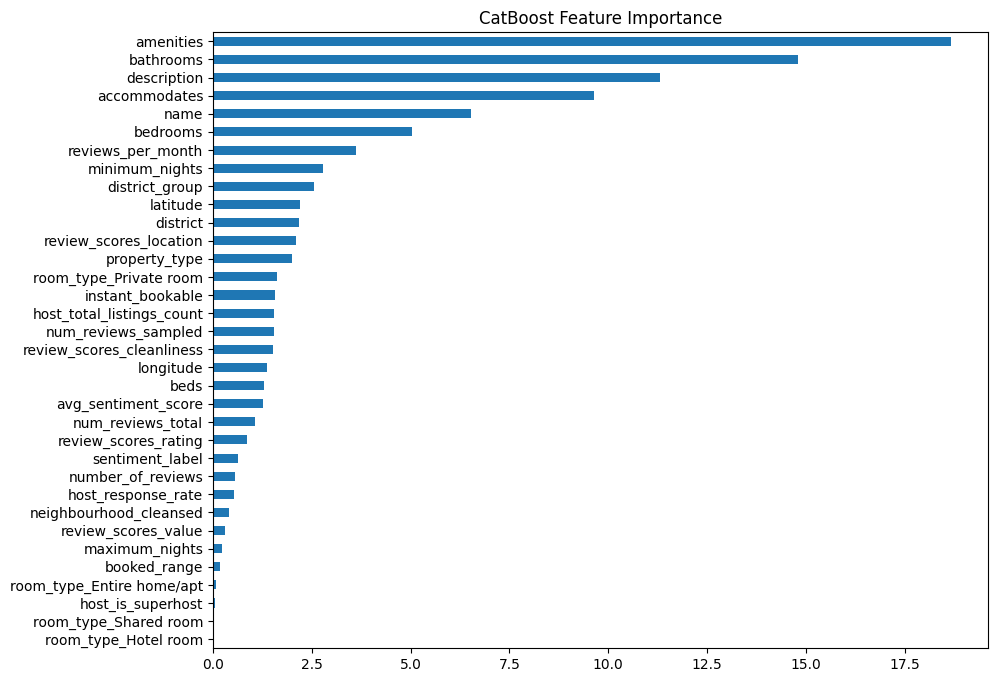

In [ ]:
importances = model.get_feature_importance()
feat_names = X_train.columns

pd.Series(importances, index=feat_names).sort_values().plot(kind="barh", figsize=(10,8))
plt.title("CatBoost Feature Importance")
plt.show()

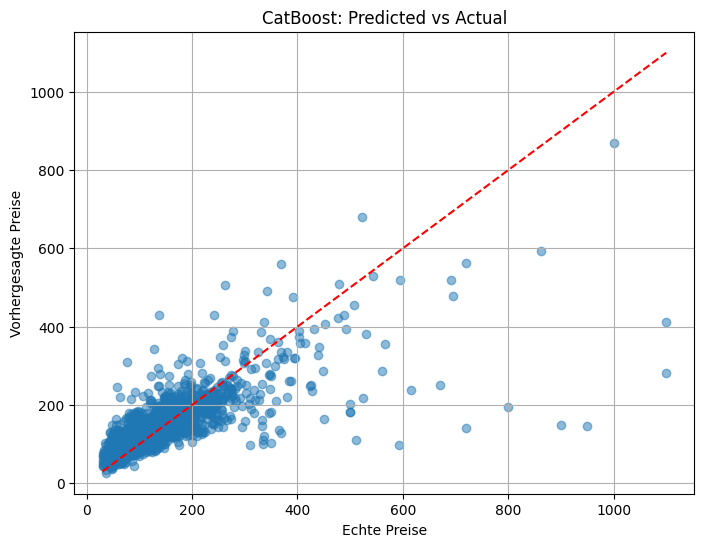

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("real")
plt.ylabel("pred")
plt.title("CatBoost: Predicted vs Actual")
plt.grid(True)
plt.show()

## Hyperparameter Tuning

In [ ]:
# learning_rate

learning_rates = [0.01, 0.05, 0.1, 0.2]
results = []  # MAE/RMSE for every run

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=lr,
        depth=8,
        loss_function="RMSE",
        random_state=42,
        verbose=False
    )
    model.fit(
        X_train, y_train,
        cat_features= categorical_features,
        text_features= text_features,
        eval_set=(X_test, y_test)
    )

    # Evaluation
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({"learning_rate": lr, "MAE": mae, "RMSE": rmse})

    # Learning Curve for each learning_rate
    curve = model.get_evals_result()
    axes[i].plot(curve["learn"]["RMSE"], label="Train")
    axes[i].plot(curve["validation"]["RMSE"], label="Validation")
    axes[i].set_title(f"learning_rate={lr}")
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Learning Curves – verschiedene learning_rates", fontsize=14)
plt.tight_layout()
plt.savefig("tuning_learning_rate.png")
plt.show()
print("✅ Gespeichert als tuning_learning_rate.png")

results_df = pd.DataFrame(results)
print(results_df)

0:	learn: 112.2834938	test: 104.9180831	best: 104.9180831 (0)	total: 917ms	remaining: 7m 37s


0:	learn: 113.4876916	test: 106.1757064	best: 106.1757064 (0)	total: 748ms	remaining: 6m 13s
100:	learn: 95.8262214	test: 90.0865799	best: 90.0865799 (100)	total: 1m 6s	remaining: 4m 23s
200:	learn: 87.9461653	test: 84.2012100	best: 84.2012100 (200)	total: 2m 7s	remaining: 3m 9s
300:	learn: 83.7822095	test: 81.8055292	best: 81.8029517 (299)	total: 3m 7s	remaining: 2m 3s
400:	learn: 80.8799824	test: 80.5252086	best: 80.5252086 (400)	total: 4m 8s	remaining: 1m 1s
499:	learn: 78.8403458	test: 79.7271174	best: 79.7271174 (499)	total: 5m 12s	remaining: 0us

bestTest = 79.72711737
bestIteration = 499



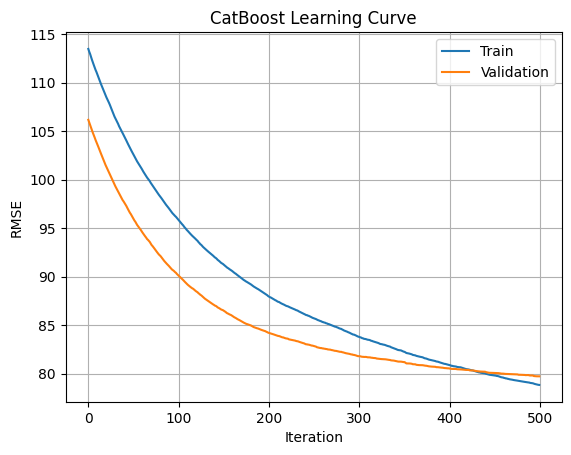

In [ ]:
# --------------- depth

depths = [4, 6, 8, 10]
results_depth = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, d in enumerate(depths):
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,  # bester Wert aus vorherigem Schritt
        depth=d,
        loss_function="RMSE",
        random_state=42,
        verbose=False
    )
    model.fit(
        X_train, y_train,
        cat_features= categorical_features,
        text_features= text_features,
        eval_set=(X_test, y_test)
    )

    y_pred = model.predict(X_test_small)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results_depth.append({"depth": d, "MAE": mae, "RMSE": rmse})

    curve = model.get_evals_result()
    axes[i].plot(curve["learn"]["RMSE"], label="Train")
    axes[i].plot(curve["validation"]["RMSE"], label="Validation")
    axes[i].set_title(f"depth={d}")
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Learning Curves – verschiedene depths", fontsize=14)
plt.tight_layout()
plt.savefig("tuning_depth.png")
plt.show()

results_depth_df = pd.DataFrame(results_depth)
print(results_depth_df)

0:	learn: 108.1579294	test: 101.5748799	best: 101.5748799 (0)	total: 509ms	remaining: 4m 13s
100:	learn: 57.4307393	test: 74.8249557	best: 74.8249557 (100)	total: 1m 5s	remaining: 4m 18s
200:	learn: 41.7152638	test: 72.2965345	best: 72.2587334 (199)	total: 2m 11s	remaining: 3m 15s
300:	learn: 32.6357895	test: 71.8583432	best: 71.7820072 (296)	total: 3m 14s	remaining: 2m 8s
400:	learn: 26.2355787	test: 71.4802151	best: 71.3041473 (366)	total: 4m 18s	remaining: 1m 3s
499:	learn: 21.3891670	test: 70.9180044	best: 70.9180044 (499)	total: 5m 19s	remaining: 0us

bestTest = 70.91800443
bestIteration = 499



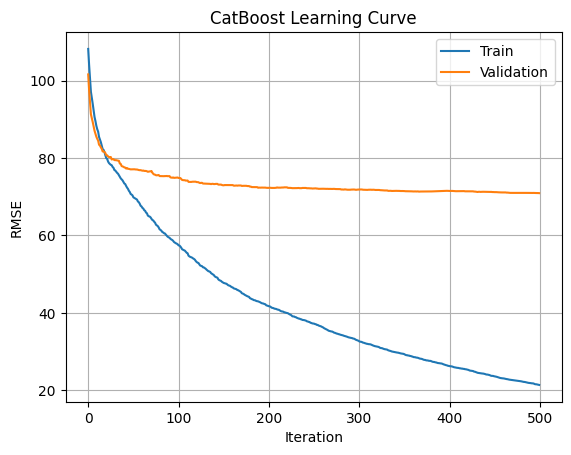

In [ ]:
# MAE & RMSE comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning Rate Vergleich
axes[0].bar(results_df["learning_rate"].astype(str), results_df["MAE"], color="steelblue")
axes[0].set_title("MAE nach learning_rate")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("MAE (€)")
axes[0].grid(axis="y")

# Depth Vergleich
axes[1].bar(results_depth_df["depth"].astype(str), results_depth_df["MAE"], color="coral")
axes[1].set_title("MAE nach depth")
axes[1].set_xlabel("depth")
axes[1].set_ylabel("MAE (€)")
axes[1].grid(axis="y")

plt.suptitle("Hyperparameter Vergleich", fontsize=14)
plt.tight_layout()
plt.savefig("hyperparameter_vergleich.png")
plt.show()
print(" Gespeichert als hyperparameter_vergleich.png")